<a href="https://colab.research.google.com/github/marcosHara/aulasDeSQL-ConsultasAvan-adas/blob/main/Avalia%C3%A7%C3%A3o1Ci%C3%AAnciasDados_Marcos_Lupion_Hara_N21(Trabalho_individual).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1° AVALIAÇÃO CIÊNCIA DE DADOS


# 1° ETAPA:

A primeira coisa que realizarão é a Análise Inicial do Dados. Lembrem-se de realizar o import das bibliotecas necessárias para análise. Certifiquem-se de que o arquivo será lido e armazenado em uma variável, além de analisarem os campos da tabela, como nome, o tipo de dado e se há valores faltantes.
	Vocês notarão que a tabela possui diversas colunas, uma delas é Total_Students, referente ao número total de estudantes de cada Universidade.
	Sobre o total de estudantes, demonstre graficamente (e explique): Podemos afirmar que a maioria das universidades possuem um total de estudantes aproximadamente igual a 20.000? (Realizem uma análise descritiva para auxiliá-los na resposta).


* Importação das Bibliotecas e armazenamento da database na variável "data frame" (df).

In [1]:
import pandas as pd #Bibliotaca para analise de Dados
import seaborn as sns #para construção de graficos simples
import matplotlib.pyplot as plt #Construção de gráficos complexos


df = pd.read_csv('top_100_universities_dataset.csv')
df.head()

,Position,University_Name,Location,Established_Year,Total_Students,Number_of_Campuses,Programs_Offered,University_Type,Total_Faculty,Campus_Area_Acres
0,1,University of Oxford,"Cambridge, Switzerland",1250,19628,3,427,Public,5843,6167
1,2,Columbia University,"Stanford, China",1432,7082,1,97,Public,2205,4239
2,3,University of Michigan,"Cambridge, China",1203,51925,11,409,Private,2105,3779
3,4,University of Edinburgh,"Singapore, USA",1777,57810,3,407,Private,3087,2376
4,5,University of Cambridge,"London, Switzerland",1104,11078,7,99,Private,7242,2917


* Analisando informações da tabela

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Position            100 non-null    int64 
 1   University_Name     100 non-null    object
 2   Location            100 non-null    object
 3   Established_Year    100 non-null    int64 
 4   Total_Students      100 non-null    int64 
 5   Number_of_Campuses  100 non-null    int64 
 6   Programs_Offered    100 non-null    int64 
 7   University_Type     100 non-null    object
 8   Total_Faculty       100 non-null    int64 
 9   Campus_Area_Acres   100 non-null    int64 
dtypes: int64(7), object(3)
memory usage: 7.9+ KB


* Usando o Pandas, vamos criar um gráfico de barras (histograma) para mostrar o total de alunos. No código, definimos o tipo do gráfico como hist, escolhemos a quantidade de colunas (bins), a cor de fundo (color), a cor das bordas (edgecolor).

<Axes: ylabel='Frequency'>

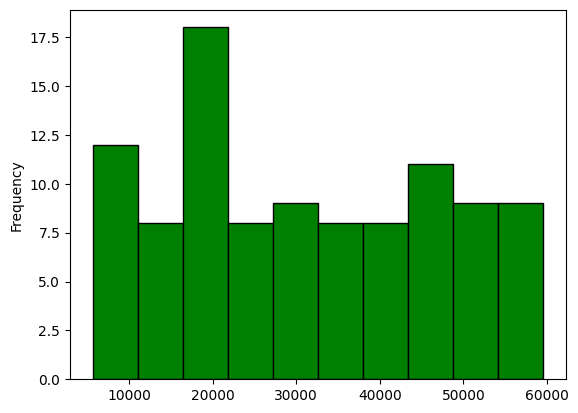

In [3]:
df['Total_Students'].plot(kind='hist',bins=10, color='green', edgecolor='black')

* Para começar, definimos que o nosso conjunto de dados se chama Total de Estudantes (Total_Students). Para entender esses números de forma rápida, usamos o comando describe(), que mostra um resumo com o total de registros, a média de alunos, o desvio padrão e os valores mínimo e máximo, além das divisões de 25%, 50% e 75% dos dados.

In [4]:
total_estudantes = df['Total_Students']
total_estudantes.describe()

,Total_Students
count,100.000000
mean,30987.750000
std,16151.022481
min,5633.000000
25%,18966.500000
50%,28476.500000
75%,46455.500000
max,59584.000000


* Usando a biblioteca Seaborn, criamos um gráfico chamado boxplot. Ele é mais preciso que o histograma para esta análise porque mostra que os dados estão bem equilibrados, sem valores 'perdidos' fora do padrão.

Com ele, concluímos que a maioria das universidades tem entre 30.000 e 45.000 alunos.

<Axes: ylabel='Total_Students'>

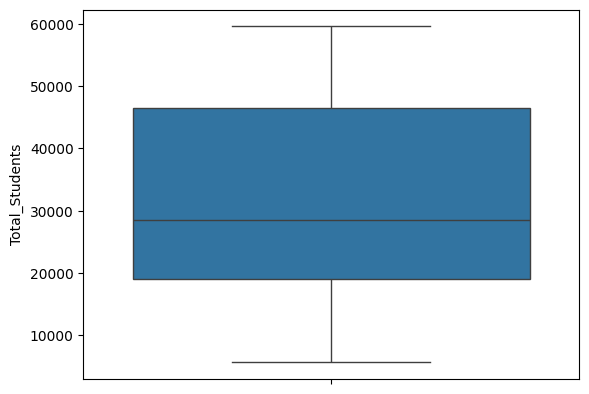

In [5]:
sns.boxplot(df['Total_Students'])

# 2° ETAPA:


Outra coluna existente é a University_Type (Tipo da Universidade), que informa se a Universidade é pública ou privada. Deseja-se saber a quantidade de Universidades públicas e privadas, demonstradas e explicadas graficamente. (Podem começar isolando os valores Public e Private, utilizem funções como value_counts( ), to_frame( ) e reset_index( ). Criem um dicionário para armazenar o total das universidades que são públicas e privadas, transformando-o em um DataFrame para poderem plotar os gráficos).

* Aqui vemos o tipo da universidade (publica ou privada) e o numero total de universidades de cada tipo

In [6]:
uni_type = df['University_Type'].value_counts().to_frame().reset_index()
uni_type.head()

,University_Type,count
0,Private,51
1,Public,49


* Um Dicionario das informações das universidades publicas e privadas, podendo assim plotar os graficos.

In [7]:
total_uni = df.value_counts('University_Type')
total_geral = total_uni.sum()
total_privada = total_uni.loc['Private']
total_publica = total_geral - total_privada
print(total_privada, total_publica)

51 49


* Com os dados organizados, criamos um histograma (hist) para comparar os tipos de faculdades. O gráfico mostra que a quantidade de universidades públicas e particulares é bem parecida.
Isso indica que não existe uma grande diferença entre elas e que os alunos, mesmo com menos recursos financeiros, têm boas chances de entrar em diversas instituições públicas.

<Axes: xlabel='Tipo da Universidade', ylabel='Total'>

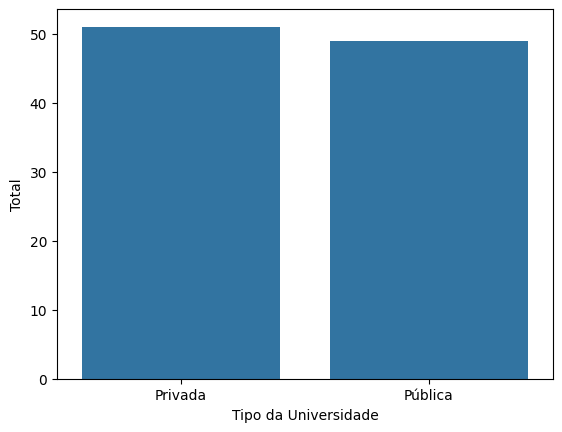

In [8]:
dados = {
    "Tipo da Universidade": ['Privada', 'Pública'],
    "Total": [total_privada, total_publica]
}

dados = pd.DataFrame(dados)
sns.barplot(x='Tipo da Universidade', y='Total', data=dados)

* Ao criarmos um gráfico de pizza, confirmamos o que vimos no histograma: existe apenas uma pequena diferença entre o número de universidades públicas e particulares.
Isso reforça que a desigualdade não é grande, mostrando que os alunos têm boas oportunidades de entrar em diversas instituições públicas, mesmo que não tenham condições financeiras.

([<matplotlib.patches.Wedge at 0x7946066a0950>,
 [Text(-0.03455189711247168, 1.0994572144498982, 'Privada'),
  Text(0.03455186216456442, -1.0994572155481819, 'Pública')])

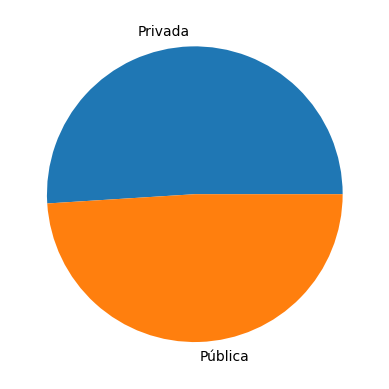

In [9]:
plt.pie(dados['Total'], labels = dados['Tipo da Universidade'])